In [1]:
# Q10. Kurtosis and Heavy Tails


# Compute and compare the kurtosis (scipy.stats.kurtosis) of: (a) normal distribution, n=1000; (b) tdistribution with df=3 (heavy tails); (c) uniform distribution. Create a single matplotlib figure overlaying
# all three PDFs (use scipy.stats distribution objects for x-range and .pdf(x)). Add a text annotation
# showing each distribution's kurtosis value on the plot.
# Answer: which of these distributions would cause the most problems for an ML model that assumes
# normally distributed features?
# � Hint: stats.t(df=3).pdf(x) gives you the t-distribution PDF. stats.norm(0,1).pdf(x) for normal. Kurtosis > 0 =
# heavier tails than normal.


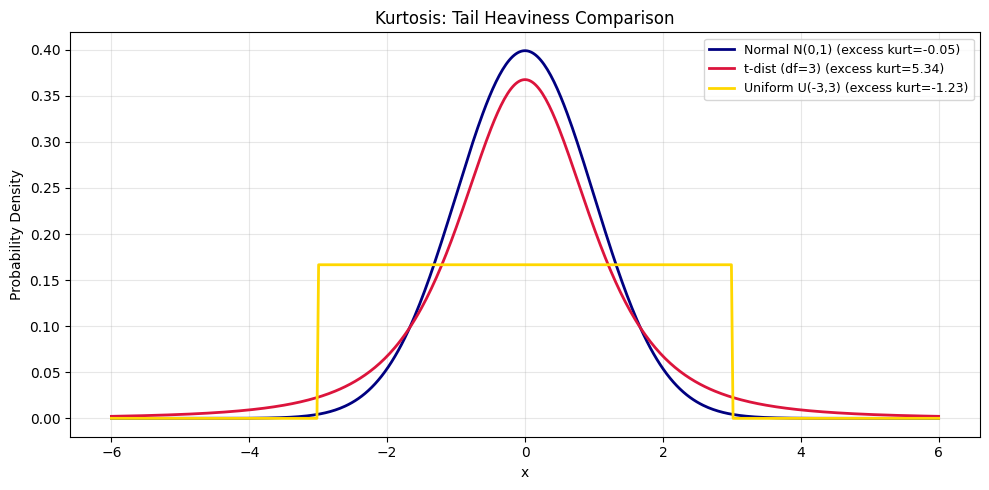

In [5]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(0)

x=np.linspace(-6, 6, 500)

distributions=[
    ('Normal N(0,1)', stats.norm(0,1), np.random.normal(0,1,1000)),
    ('t-dist (df=3)', stats.t(3), np.random.standard_t(3, 1000)),
    ('Uniform U(-3,3)', stats.uniform(-3, 6), np.random.uniform(-3,3,1000)),
]

fig, ax=plt.subplots(figsize=(10,5))
colors=['navy', 'crimson', 'gold']

for (name, dist, sample), color in zip(distributions, colors):
    kurt=stats.kurtosis(sample)  # excess kurtosis (normal=0)
    ax.plot(x, dist.pdf(x), color=color, lw=2, label=f'{name} (excess kurt={kurt:.2f})')

ax.set_title('Kurtosis: Tail Heaviness Comparison')
ax.set_xlabel('x');
ax.set_ylabel('Probability Density')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()